In [1]:
# Block 1
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
# Block 2
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# One-hot encoding
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Block 3
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Block 4
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train,y_train,
                    epochs=5,
                    validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9587 - loss: 0.1369 - val_accuracy: 0.9864 - val_loss: 0.0406
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9862 - loss: 0.0444 - val_accuracy: 0.9856 - val_loss: 0.0455
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9911 - loss: 0.0300 - val_accuracy: 0.9886 - val_loss: 0.0348
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9933 - loss: 0.0210 - val_accuracy: 0.9903 - val_loss: 0.0253
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9944 - loss: 0.0163 - val_accuracy: 0.9879 - val_loss: 0.0383


In [5]:
# Block 5
test_loss, test_acc = model.evaluate(x_test,y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9879 - loss: 0.0383
Test Accuracy: 0.9879000186920166


In [6]:
# Select a test image
index = 0

img = x_test[index]

# Model expects batch input
img_input = np.expand_dims(img, axis=0)

# Predict
prediction = model.predict(img_input)

predicted_label = np.argmax(prediction)

print("Predicted Digit:", predicted_label)
print("Actual Digit:", y_test[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
Predicted Digit: 7
Actual Digit: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

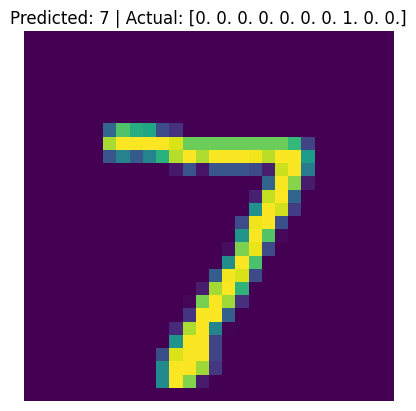

In [7]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Predicted: {predicted_label} | Actual: {y_test[index]}")
plt.axis("off")